# Notebook 11: Filter Line Search

In previous notebooks we built a working interior-point method for bound-constrained problems.
Once we add general equality and inequality constraints the standard Armijo backtracking
line search breaks down: a step that decreases the objective can increase constraint violation,
and vice-versa.  This notebook develops the **filter line search** of Fletcher & Leyffer (2002),
which elegantly resolves the conflict by treating (constraint-violation, objective) as a
bi-objective pair and maintaining a *Pareto front* (the filter) of accepted iterates.

**Learning objectives**
- Understand why merit functions fail for constrained problems
- Implement the filter data-structure and its dominance test
- Code the switching condition between filter and Armijo acceptance
- Add second-order corrections (SOC) for robustness
- Visualize the filter evolving during an IPM solve

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from scipy.linalg import solve, lstsq

np.random.seed(42)
plt.rcParams['figure.dpi'] = 100

## 1. Why Armijo Fails for Constrained Problems

For unconstrained minimization, the Armijo condition
$$f(x + \alpha d) \le f(x) + c_1 \alpha \nabla f(x)^T d$$
is sufficient to guarantee progress.  For constrained problems we want **both**
$$\text{constraint violation: } \theta(x) = \|g(x)\|_\infty \to 0$$
$$\text{barrier objective: } \phi(x) = f(x) - \mu \sum_i \log(s_i) \to \text{min}$$

These two goals **compete**. A step toward feasibility often increases $f$.

### The merit function approach
A classical remedy is a penalty merit function
$$\psi(x) = f(x) + \rho \|g(x)\|$$
but choosing $\rho$ is hard: too small and feasibility is ignored; too large and
the Hessian of $\psi$ becomes ill-conditioned.

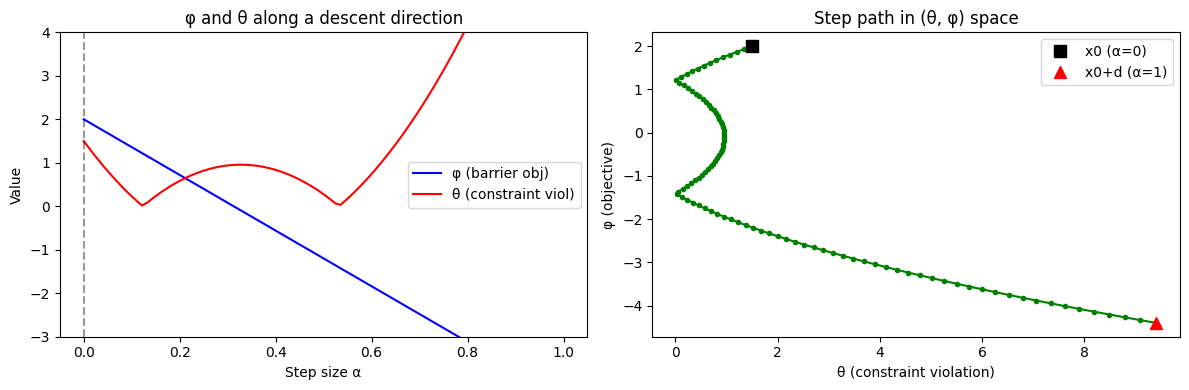

At α=0:   θ=1.5000, φ=2.0000
At α=0.5: θ=0.2345, φ=-1.2323
At α=1:   θ=9.4000, φ=-4.4000


In [2]:
# Illustrate the conflict on a simple 2D problem
# min f(x) = x1 + x2  s.t.  g(x) = x1^2 + x2^2 - 1 = 0
# Optimal: x* = (-1/sqrt(2), -1/sqrt(2)), f* = -sqrt(2)

def f_circle(x):
    return x[0] + x[1]

def g_circle(x):
    return np.array([x[0]**2 + x[1]**2 - 1.0])

def grad_f_circle(x):
    return np.array([1.0, 1.0])

def jac_g_circle(x):
    return np.array([[2*x[0], 2*x[1]]])

# Starting point and a Newton-like direction
x0 = np.array([0.5, 1.5])
J = jac_g_circle(x0)
gval = g_circle(x0)
# Constrained Newton direction: project gradient onto constraint
d_newton = -grad_f_circle(x0) + J.T @ np.linalg.solve(J @ J.T, J @ grad_f_circle(x0) - gval / 0.1)

alphas = np.linspace(0, 1, 100)
phi_vals = [f_circle(x0 + a * d_newton) for a in alphas]
theta_vals = [np.linalg.norm(g_circle(x0 + a * d_newton), np.inf) for a in alphas]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(alphas, phi_vals, 'b-', label='φ (barrier obj)')
axes[0].plot(alphas, theta_vals, 'r-', label='θ (constraint viol)')
axes[0].axvline(0.0, color='k', linestyle='--', alpha=0.4)
axes[0].set_xlabel('Step size α')
axes[0].set_ylabel('Value')
axes[0].set_title('φ and θ along a descent direction')
axes[0].legend()
axes[0].set_ylim(-3, 4)

axes[1].plot(theta_vals, phi_vals, 'g-o', markersize=3)
axes[1].plot(theta_vals[0], phi_vals[0], 'ks', markersize=8, label='x0 (α=0)')
axes[1].plot(theta_vals[-1], phi_vals[-1], 'r^', markersize=8, label='x0+d (α=1)')
axes[1].set_xlabel('θ (constraint violation)')
axes[1].set_ylabel('φ (objective)')
axes[1].set_title('Step path in (θ, φ) space')
axes[1].legend()

plt.tight_layout()
plt.show()
print("At α=0:   θ={:.4f}, φ={:.4f}".format(theta_vals[0], phi_vals[0]))
print("At α=0.5: θ={:.4f}, φ={:.4f}".format(theta_vals[50], phi_vals[50]))
print("At α=1:   θ={:.4f}, φ={:.4f}".format(theta_vals[-1], phi_vals[-1]))

## 2. The Filter Concept (Fletcher & Leyffer 2002)

The filter is a set $\mathcal{F}$ of pairs $(\theta_k, \phi_k)$ from previous iterates.
A trial point $(\theta_{\text{trial}}, \phi_{\text{trial}})$ is **dominated** by filter entry
$(\theta_k, \phi_k)$ if
$$\theta_{\text{trial}} \ge \theta_k \quad \text{AND} \quad \phi_{\text{trial}} \ge \phi_k$$
(both coordinates are at least as bad).

A trial point is **acceptable to the filter** if it is **not dominated** by any entry.

But we also require a minimum improvement margin (to prevent stagnation):
$$\theta_{\text{trial}} \le (1-\gamma_\theta)\theta_{\text{cur}} \quad \text{OR} \quad
  \phi_{\text{trial}} \le \phi_{\text{cur}} - \gamma_\phi \theta_{\text{cur}}$$
with $\gamma_\theta = \gamma_\phi = 10^{-5}$.

In [3]:
class Filter:
    """
    Fletcher-Leyffer filter for constrained optimization.

    The filter stores pairs (theta, phi) representing constraint violation
    and barrier objective at accepted iterates.  A new point is acceptable
    if it is not dominated by any stored pair.
    """

    def __init__(self, theta_max=1e4):
        """
        theta_max: initial filter entry to prevent very infeasible steps.
        """
        self.entries = []  # list of (theta, phi) pairs
        self.theta_max = theta_max
        # Add an upper bound on constraint violation
        self.entries.append((theta_max, -np.inf))

    def dominates(self, theta_k, phi_k, theta_trial, phi_trial):
        """Return True if (theta_k, phi_k) dominates (theta_trial, phi_trial)."""
        return (theta_trial >= theta_k) and (phi_trial >= phi_k)

    def is_acceptable(self, theta_trial, phi_trial, gamma_theta=1e-5, gamma_phi=1e-5,
                      theta_cur=None, phi_cur=None):
        """
        Check whether (theta_trial, phi_trial) is acceptable to the filter.

        Returns (acceptable, reason) where reason is 'not_dominated', 'margin_theta',
        'margin_phi', or 'dominated'.
        """
        # Step 1: check filter domination
        for (tk, pk) in self.entries:
            if self.dominates(tk, pk, theta_trial, phi_trial):
                return False, 'dominated'

        # Step 2: check margin improvement relative to current point
        if theta_cur is not None and phi_cur is not None:
            theta_ok = theta_trial <= (1 - gamma_theta) * theta_cur
            phi_ok   = phi_trial   <= phi_cur - gamma_phi * theta_cur
            if theta_ok:
                return True, 'margin_theta'
            if phi_ok:
                return True, 'margin_phi'
            return False, 'no_margin'

        return True, 'not_dominated'

    def add(self, theta, phi):
        """
        Add (theta, phi) to the filter, and remove any entries now dominated by it
        (to keep the filter non-dominated / minimal).
        """
        # Remove dominated entries (optional pruning for efficiency)
        new_entries = []
        for (tk, pk) in self.entries:
            # Keep entry unless the new point dominates it
            if not (theta <= tk and phi <= pk):
                new_entries.append((tk, pk))
        new_entries.append((theta, phi))
        self.entries = new_entries

    def reset(self, theta_max=None):
        """Reset the filter (called when mu decreases in IPM)."""
        if theta_max is None:
            theta_max = self.theta_max
        self.entries = [(theta_max, -np.inf)]

    def __len__(self):
        return len(self.entries)

    def __repr__(self):
        return f"Filter({len(self.entries)} entries)"


# Quick smoke test
flt = Filter(theta_max=10.0)
flt.add(5.0, 3.0)
flt.add(2.0, 7.0)
print("Filter entries:", flt.entries)

tests = [
    (6.0, 4.0, "should be dominated by (5,3)"),
    (1.0, 6.0, "should be acceptable (θ improved)"),
    (3.0, 8.0, "should be dominated by (2,7)"),
    (1.0, 1.0, "should be acceptable (both improved)"),
]
for theta, phi, desc in tests:
    ok, reason = flt.is_acceptable(theta, phi)
    print(f"  (θ={theta}, φ={phi}): acceptable={ok}, reason={reason} — {desc}")

Filter entries: [(10.0, -inf), (5.0, 3.0), (2.0, 7.0)]
  (θ=6.0, φ=4.0): acceptable=False, reason=dominated — should be dominated by (5,3)
  (θ=1.0, φ=6.0): acceptable=True, reason=not_dominated — should be acceptable (θ improved)
  (θ=3.0, φ=8.0): acceptable=False, reason=dominated — should be dominated by (2,7)
  (θ=1.0, φ=1.0): acceptable=True, reason=not_dominated — should be acceptable (both improved)


## 3. Visualizing the Filter

In $(\theta, \phi)$ space the filter entries form a *staircase* boundary.
Any point *above and to the right* of some step is dominated (rejected).
The acceptable region lies below-left of the entire staircase.

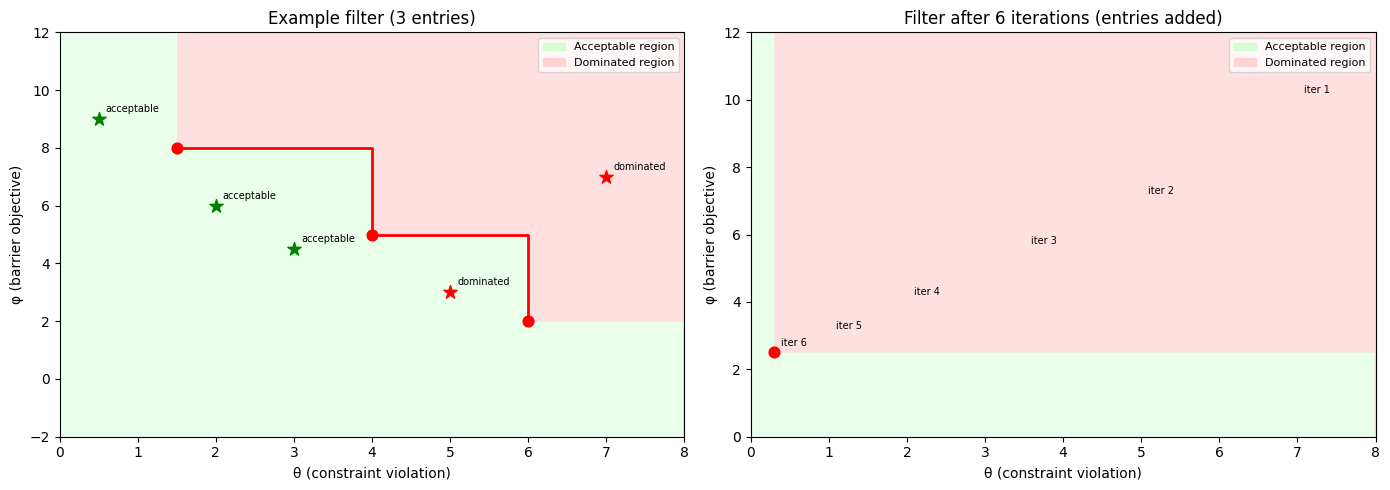

In [4]:
def plot_filter(flt, ax, theta_range=(0, 8), phi_range=(-2, 12), title='Filter'):
    """Visualise the filter's dominated and acceptable regions."""
    # Colour the dominated region
    theta_pts = np.linspace(*theta_range, 300)
    phi_pts   = np.linspace(*phi_range, 300)
    TH, PH = np.meshgrid(theta_pts, phi_pts)

    dominated = np.zeros(TH.shape, dtype=bool)
    for (tk, pk) in flt.entries:
        dominated |= (TH >= tk) & (PH >= pk)

    ax.contourf(TH, PH, dominated.astype(float), levels=[0.5, 1.5],
                colors=['#ffcccc'], alpha=0.6)
    ax.contourf(TH, PH, (~dominated).astype(float), levels=[0.5, 1.5],
                colors=['#ccffcc'], alpha=0.4)

    # Draw the staircase boundary
    entries_sorted = sorted([(t, p) for t, p in flt.entries if t < theta_range[1]], key=lambda e: e[0])
    if entries_sorted:
        ts = [theta_range[0]] + [e[0] for e in entries_sorted] + [theta_range[1]]
        ps = [entries_sorted[0][1]] + [e[1] for e in entries_sorted] + [entries_sorted[-1][1]]
        # Build staircase
        sx, sy = [], []
        for i in range(len(entries_sorted)):
            sx.append(entries_sorted[i][0])
            sy.append(entries_sorted[i][1])
            if i + 1 < len(entries_sorted):
                sx.append(entries_sorted[i+1][0])
                sy.append(entries_sorted[i][1])
        ax.plot(sx, sy, 'r-', linewidth=2, label='Filter boundary')

    # Plot filter entries
    fentries = [(t, p) for t, p in flt.entries if p > -1e3]
    if fentries:
        ax.scatter(*zip(*fentries), color='red', s=60, zorder=5, label='Filter entries')

    ax.set_xlim(*theta_range)
    ax.set_ylim(*phi_range)
    ax.set_xlabel('θ (constraint violation)')
    ax.set_ylabel('φ (barrier objective)')
    ax.set_title(title)
    ax.legend(loc='upper right', fontsize=8)
    green_patch = mpatches.Patch(color='#ccffcc', alpha=0.8, label='Acceptable region')
    red_patch   = mpatches.Patch(color='#ffcccc', alpha=0.8, label='Dominated region')
    ax.legend(handles=[green_patch, red_patch], loc='upper right', fontsize=8)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

flt_demo = Filter(theta_max=8.0)
flt_demo.add(6.0, 2.0)
flt_demo.add(4.0, 5.0)
flt_demo.add(1.5, 8.0)
plot_filter(flt_demo, axes[0], theta_range=(0, 8), phi_range=(-2, 12), title='Example filter (3 entries)')

# Show some trial points
trial_points = [
    (5.0, 3.0, 'red',   'dominated'),
    (3.0, 4.5, 'green', 'acceptable'),
    (0.5, 9.0, 'green', 'acceptable'),
    (2.0, 6.0, 'green', 'acceptable'),
    (7.0, 7.0, 'red',   'dominated'),
]
for (t, p, c, lbl) in trial_points:
    axes[0].scatter(t, p, color=c, s=100, marker='*', zorder=10)
    axes[0].annotate(lbl, (t, p), fontsize=7, xytext=(5, 5), textcoords='offset points')

# Second plot: filter evolving over iterations
flt_evolving = Filter(theta_max=8.0)
iter_points  = [(7.0, 10.0), (5.0, 7.0), (3.5, 5.5), (2.0, 4.0), (1.0, 3.0), (0.3, 2.5)]
for tp in iter_points:
    flt_evolving.add(*tp)
plot_filter(flt_evolving, axes[1], theta_range=(0, 8), phi_range=(0, 12),
            title='Filter after 6 iterations (entries added)')
for i, (t, p) in enumerate(iter_points):
    axes[1].annotate(f'iter {i+1}', (t, p), fontsize=7, xytext=(5, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

## 4. The Switching Condition

When the iterates are already nearly feasible ($\theta < \theta_{\min}$) we can afford
to ignore the filter and just require Armijo descent on $\phi$.  This is the
**switching condition** (Wächter & Biegler 2006):

$$\nabla\phi(x)^T d < 0 \quad \text{AND} \quad
  \underbrace{(-\nabla\phi \cdot d)^{s_\phi}}_{\text{steepness}} > \delta \cdot \theta^{s_\theta}$$

with constants $\delta = 10^{-4}$, $s_\phi = 2.3$, $s_\theta = 1.1$.

When the switching condition fires, use the **Armijo** condition:
$$\phi(x + \alpha d) \le \phi(x) + \eta_\phi \alpha \nabla\phi(x)^T d$$
with $\eta_\phi = 10^{-8}$ (very mild).

Otherwise use the **filter** acceptance condition.

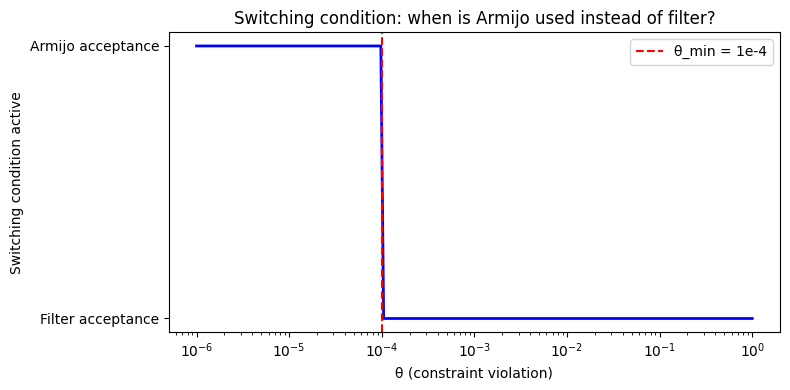

Switching fires when θ < θ_min AND direction is sufficiently steep.
With ∇φ·d = -0.5, switching fires for θ below: 9.77e-05


In [5]:
def switching_condition(dphi_dot_d, theta, delta=1e-4, s_phi=2.3, s_theta=1.1,
                        theta_min=1e-4):
    """
    Return True if the switching condition is satisfied.
    When True, use Armijo (not filter) acceptance.
    """
    if theta < theta_min and dphi_dot_d < 0:
        steepness = (-dphi_dot_d) ** s_phi
        threshold = delta * theta ** s_theta
        return steepness > threshold
    return False


def armijo_condition(phi_trial, phi_cur, alpha, dphi_dot_d, eta_phi=1e-8):
    """Armijo sufficient decrease condition."""
    return phi_trial <= phi_cur + eta_phi * alpha * dphi_dot_d


# Illustrate when switching fires
theta_vals_sw = np.logspace(-6, 0, 200)
dphi_dd = -0.5  # moderate descent in phi

fires = [switching_condition(dphi_dd, t) for t in theta_vals_sw]

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(theta_vals_sw, fires, 'b-', linewidth=2)
ax.axvline(1e-4, color='r', linestyle='--', label='θ_min = 1e-4')
ax.set_xlabel('θ (constraint violation)')
ax.set_ylabel('Switching condition active')
ax.set_title('Switching condition: when is Armijo used instead of filter?')
ax.set_yticks([0, 1])
ax.set_yticklabels(['Filter acceptance', 'Armijo acceptance'])
ax.legend()
plt.tight_layout()
plt.show()

print("Switching fires when θ < θ_min AND direction is sufficiently steep.")
print(f"With ∇φ·d = {dphi_dd}, switching fires for θ below:", end=' ')
thresholds = [t for t in theta_vals_sw if switching_condition(dphi_dd, t)]
if thresholds:
    print(f"{max(thresholds):.2e}")
else:
    print("(never)")

## 5. Complete Filter Line Search

Putting it together: given a current point $x$, direction $d$, and filter, the
**filter line search** backtracks $\alpha = 1, \tfrac{1}{2}, \tfrac{1}{4}, \ldots$
until a trial point is accepted by either Armijo (switching condition) or the filter.

In [6]:
def filter_line_search(x, d, phi_fn, grad_phi_fn, theta_fn,
                       flt, alpha_init=1.0, alpha_min=1e-12,
                       gamma_theta=1e-5, gamma_phi=1e-5,
                       eta_phi=1e-8, delta=1e-4, s_phi=2.3, s_theta=1.1,
                       theta_min=1e-4, verbose=False):
    """
    Filter line search.

    Parameters
    ----------
    x         : current point (n,)
    d         : search direction (n,)
    phi_fn    : callable, barrier objective
    grad_phi_fn: callable, gradient of phi
    theta_fn  : callable, constraint violation (scalar)
    flt       : Filter instance
    alpha_init: initial step size

    Returns
    -------
    x_new, alpha, accepted, reason
    """
    phi_cur   = phi_fn(x)
    theta_cur = theta_fn(x)
    grad_phi  = grad_phi_fn(x)
    dphi_dot_d = grad_phi @ d

    use_armijo = switching_condition(dphi_dot_d, theta_cur, delta, s_phi, s_theta, theta_min)
    if verbose:
        print(f"  φ={phi_cur:.4f}, θ={theta_cur:.4e}, ∇φ·d={dphi_dot_d:.4f}, Armijo={use_armijo}")

    alpha = alpha_init
    while alpha >= alpha_min:
        x_trial     = x + alpha * d
        phi_trial   = phi_fn(x_trial)
        theta_trial = theta_fn(x_trial)

        if use_armijo:
            ok = armijo_condition(phi_trial, phi_cur, alpha, dphi_dot_d, eta_phi)
            reason = 'armijo' if ok else 'armijo_rejected'
        else:
            ok, reason = flt.is_acceptable(theta_trial, phi_trial,
                                           gamma_theta, gamma_phi,
                                           theta_cur, phi_cur)

        if verbose:
            print(f"    α={alpha:.2e}: φ_trial={phi_trial:.4f}, θ_trial={theta_trial:.4e} → {reason}")

        if ok:
            return x_trial, alpha, True, reason

        alpha *= 0.5

    return x + alpha_init * d, alpha_init, False, 'line_search_failed'


# Demo on the circle problem
# Starting point on the outside
x_start = np.array([1.2, 0.8])
flt_demo2 = Filter(theta_max=5.0)

def phi_circle(x):
    return f_circle(x) - 0.5 * np.log(max(1 - x[0]**2 - x[1]**2 + 2, 1e-10))

def grad_phi_circle(x):
    denom = max(1 - x[0]**2 - x[1]**2 + 2, 1e-10)
    return np.array([1 + 0.5 * 2*x[0]/denom, 1 + 0.5 * 2*x[1]/denom])

def theta_circle(x):
    return np.abs(x[0]**2 + x[1]**2 - 1.0)

# Direction toward feasibility and descent
J_cur = jac_g_circle(x_start)
g_cur = g_circle(x_start)
d_feas = -J_cur.T @ g_cur  # feasibility direction
d_feas /= np.linalg.norm(d_feas) + 1e-10

x_new, alpha, accepted, reason = filter_line_search(
    x_start, d_feas, phi_circle, grad_phi_circle, theta_circle,
    flt_demo2, alpha_init=1.0, verbose=True
)
print(f"\nResult: accepted={accepted}, α={alpha:.4f}, reason={reason}")
print(f"  x_start = {x_start}")
print(f"  x_new   = {x_new}")
print(f"  θ: {theta_circle(x_start):.4f} → {theta_circle(x_new):.4f}")
print(f"  φ: {phi_circle(x_start):.4f} → {phi_circle(x_new):.4f}")

  φ=2.0417, θ=1.0800e+00, ∇φ·d=-2.9544, Armijo=False
    α=1.00e+00: φ_trial=0.0976, θ_trial=8.0444e-01 → margin_theta

Result: accepted=True, α=1.0000, reason=margin_theta
  x_start = [1.2 0.8]
  x_new   = [0.36794971 0.2452998 ]
  θ: 1.0800 → 0.8044
  φ: 2.0417 → 0.0976


## 6. Second-Order Corrections (SOC)

Sometimes the filter rejects a step primarily because the constraint violation
increased, not because $\phi$ got worse.  A **second-order correction** fixes
the feasibility issue while keeping the same descent direction.

Given the trial point $x_{\text{trial}} = x + \alpha d$, compute a correction $d_{\text{soc}}$
that reduces the constraint residual at $x_{\text{trial}}$:
$$J(x_{\text{trial}}) \, d_{\text{soc}} = -g(x_{\text{trial}})$$
(or least-squares if $J$ is not square).  Then try $x + \alpha d + d_{\text{soc}}$.

In [7]:
def second_order_correction(x_trial, g_fn, jac_g_fn, max_soc=4):
    """
    Compute a second-order correction step to reduce constraint violation at x_trial.

    Solves (in least-squares sense): J(x_trial) * d_soc = -g(x_trial)

    Returns d_soc (n,)
    """
    g_trial = g_fn(x_trial)
    J_trial = jac_g_fn(x_trial)
    # Least-squares solution: d_soc = -J^+ g  (J^+ = pseudo-inverse)
    d_soc, _, _, _ = lstsq(J_trial, -g_trial)
    return d_soc


def filter_line_search_with_soc(x, d, phi_fn, grad_phi_fn, theta_fn,
                                g_fn, jac_g_fn, flt,
                                alpha_init=1.0, alpha_min=1e-12,
                                gamma_theta=1e-5, gamma_phi=1e-5,
                                kappa_soc=0.99, max_soc=4, verbose=False):
    """
    Filter line search with second-order corrections.
    On each backtracking step where theta increases, attempt a SOC.
    """
    phi_cur   = phi_fn(x)
    theta_cur = theta_fn(x)
    grad_phi  = grad_phi_fn(x)
    dphi_dot_d = grad_phi @ d

    use_armijo = switching_condition(dphi_dot_d, theta_cur)

    alpha = alpha_init
    soc_count = 0

    while alpha >= alpha_min:
        x_trial     = x + alpha * d
        phi_trial   = phi_fn(x_trial)
        theta_trial = theta_fn(x_trial)

        # Primary acceptance check
        if use_armijo:
            ok = armijo_condition(phi_trial, phi_cur, alpha, dphi_dot_d)
            reason = 'armijo'
        else:
            ok, reason = flt.is_acceptable(theta_trial, phi_trial,
                                           gamma_theta, gamma_phi,
                                           theta_cur, phi_cur)

        if ok:
            if verbose:
                print(f"  Accepted at α={alpha:.4f}, reason={reason}")
            return x_trial, alpha, True, reason

        # If theta increased and we have SOC budget, try correction
        if theta_trial > theta_cur and soc_count < max_soc:
            d_soc = second_order_correction(x_trial, g_fn, jac_g_fn)
            x_soc       = x_trial + d_soc
            phi_soc     = phi_fn(x_soc)
            theta_soc   = theta_fn(x_soc)

            # Accept SOC if it sufficiently reduces theta
            if theta_soc <= kappa_soc * theta_trial:
                ok_soc, reason_soc = flt.is_acceptable(theta_soc, phi_soc,
                                                        gamma_theta, gamma_phi,
                                                        theta_cur, phi_cur)
                if ok_soc:
                    if verbose:
                        print(f"  SOC accepted at α={alpha:.4f}, θ: {theta_trial:.4e}→{theta_soc:.4e}")
                    return x_soc, alpha, True, 'soc_' + reason_soc
            soc_count += 1

        if verbose:
            print(f"  α={alpha:.2e} rejected: φ={phi_trial:.4f}, θ={theta_trial:.4e}")
        alpha *= 0.5

    return x + alpha_init * d, alpha_init, False, 'line_search_failed'


# Demonstrate SOC benefit: start from a point where basic filter would fail
print("Demonstrating SOC: starting from a challenging infeasible point")
x_infeas = np.array([0.3, 1.4])
flt_soc = Filter(theta_max=2.0)
# Add a restrictive filter entry to simulate partially-solved problem
flt_soc.add(0.5, 2.5)

# Use a direction that primarily reduces phi but slightly increases theta
d_test = np.array([-0.8, -0.6])

result_basic = filter_line_search(
    x_infeas, d_test, phi_circle, grad_phi_circle, theta_circle,
    flt_soc, verbose=True
)
print(f"Without SOC: accepted={result_basic[2]}, reason={result_basic[3]}")

flt_soc2 = Filter(theta_max=2.0)
flt_soc2.add(0.5, 2.5)
result_soc = filter_line_search_with_soc(
    x_infeas, d_test, phi_circle, grad_phi_circle, theta_circle,
    g_circle, jac_g_circle, flt_soc2, verbose=True
)
print(f"With SOC:    accepted={result_soc[2]}, reason={result_soc[3]}")

Demonstrating SOC: starting from a challenging infeasible point
  φ=1.7256, θ=1.0500e+00, ∇φ·d=-2.5368, Armijo=False
    α=1.00e+00: φ_trial=-0.0733, θ_trial=1.1000e-01 → margin_theta
Without SOC: accepted=True, reason=margin_theta
  Accepted at α=1.0000, reason=margin_theta
With SOC:    accepted=True, reason=margin_theta


## 7. Filter Augmentation

When a step is accepted, should we always add the current point to the filter?
**Only when using filter acceptance** (not Armijo).  Adding points to the filter
prevents returning to regions already explored.

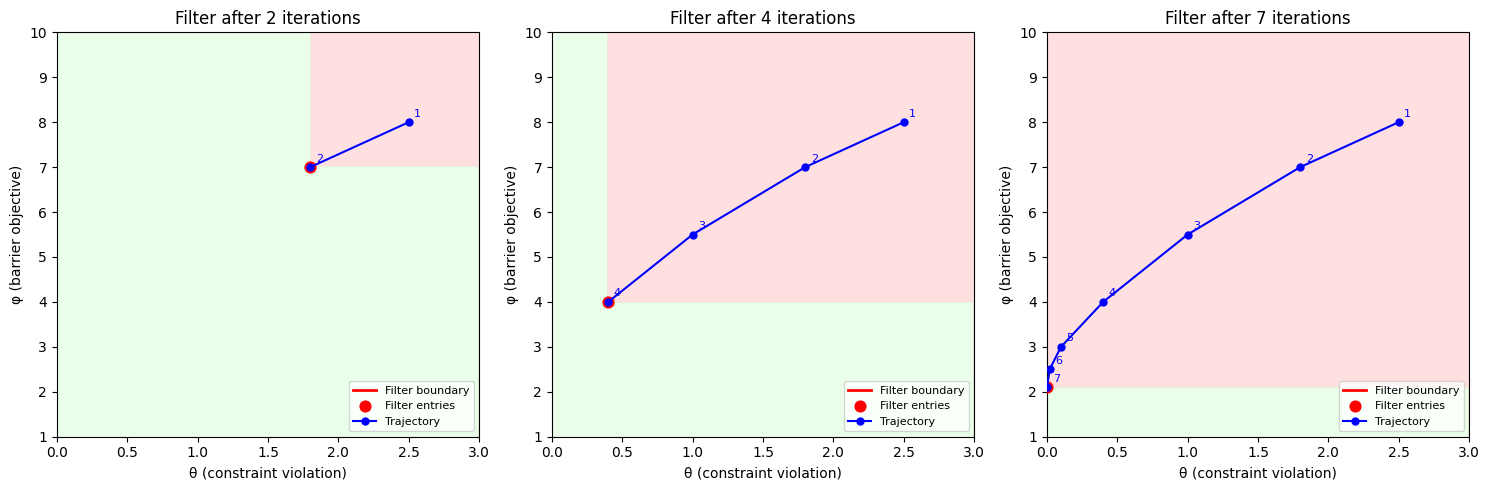

In [8]:
def augment_filter(flt, theta_cur, phi_cur, reason, beta_theta=0.999, beta_phi=0.999):
    """
    Augment filter with the current point (before a filter-accepted step).
    Only called when using filter (not Armijo) acceptance.
    The entry is (beta_theta * theta_cur, beta_phi * phi_cur) to give a margin.
    """
    if 'armijo' not in reason:  # augment only on filter acceptance
        flt.add(beta_theta * theta_cur, phi_cur)  # typical: augment on theta side


# Show how the filter grows over iterations
flt_grow = Filter(theta_max=3.0)
trajectory = [
    (2.5, 8.0),   # iter 1: highly infeasible
    (1.8, 7.0),   # iter 2
    (1.0, 5.5),   # iter 3
    (0.4, 4.0),   # iter 4
    (0.1, 3.0),   # iter 5
    (0.02, 2.5),  # iter 6
    (0.001, 2.1), # iter 7 (near feasible, switching condition fires)
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

snapshots = [2, 4, 7]
for snap_idx, ax in zip(snapshots, axes):
    flt_snap = Filter(theta_max=3.0)
    for i, (t, p) in enumerate(trajectory[:snap_idx]):
        flt_snap.add(t, p)
    plot_filter(flt_snap, ax, theta_range=(0, 3), phi_range=(1, 10),
                title=f'Filter after {snap_idx} iterations')
    path_t = [tp[0] for tp in trajectory[:snap_idx]]
    path_p = [tp[1] for tp in trajectory[:snap_idx]]
    ax.plot(path_t, path_p, 'b-o', markersize=5, label='Trajectory', zorder=8)
    for i, (t, p) in enumerate(trajectory[:snap_idx]):
        ax.annotate(str(i+1), (t, p), fontsize=8, xytext=(4, 4),
                    textcoords='offset points', color='blue')
    ax.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

## 8. Full Demo: Filter Line Search on a 2D Constrained Problem

We solve:
$$\min_{x \in \mathbb{R}^2} \; (x_1 - 2)^2 + (x_2 - 1)^2 \quad
  \text{s.t.} \; x_1^2 + x_2^2 = 1$$

using a simple projected gradient method with filter line search.

In [9]:
def f2(x):
    return (x[0] - 2)**2 + (x[1] - 1)**2

def grad_f2(x):
    return np.array([2*(x[0]-2), 2*(x[1]-1)])

def g2(x):
    return np.array([x[0]**2 + x[1]**2 - 1.0])

def jac_g2(x):
    return np.array([[2*x[0], 2*x[1]]])

def phi2(x, mu=0.01):
    return f2(x)

def grad_phi2(x, mu=0.01):
    return grad_f2(x)

def theta2(x):
    return float(np.abs(g2(x)[0]))

def constrained_step(x, mu=0.01):
    """Compute KKT-based search direction."""
    J  = jac_g2(x)
    gv = g2(x)
    gf = grad_f2(x)
    # Solve KKT system: [I, J^T; J, 0] [dx; dy] = [-gf; -gv]
    n, m = 2, 1
    K = np.zeros((n+m, n+m))
    K[:n, :n] = 2 * np.eye(n)  # Hessian of f2
    K[:n, n:] = J.T
    K[n:, :n] = J
    rhs = np.concatenate([-gf, -gv])
    try:
        sol = solve(K, rhs)
        return sol[:n]
    except np.linalg.LinAlgError:
        return -gf

# Run optimization with filter line search
x = np.array([1.5, 1.5])  # infeasible start
flt_main = Filter(theta_max=5.0)
history = {'x': [x.copy()], 'theta': [theta2(x)], 'phi': [phi2(x)], 'alpha': []}

for iteration in range(30):
    d = constrained_step(x)
    if np.linalg.norm(d) < 1e-10:
        break

    # Check convergence
    gv = g2(x)
    gf = grad_f2(x)
    J  = jac_g2(x)
    y_est = np.linalg.lstsq(J.T, -gf, rcond=None)[0]
    kkt_res = np.linalg.norm(gf + J.T @ y_est)
    cv = np.linalg.norm(gv)
    if kkt_res < 1e-8 and cv < 1e-8:
        print(f"Converged at iteration {iteration}")
        break

    x_new, alpha, accepted, reason = filter_line_search_with_soc(
        x, d,
        lambda xv: phi2(xv),
        lambda xv: grad_phi2(xv),
        theta2, g2, jac_g2,
        flt_main, alpha_init=1.0
    )

    if not accepted:
        # Fallback: feasibility step
        d_feas = -jac_g2(x).T @ g2(x)
        x_new = x + 0.1 * d_feas
        reason = 'feasibility_fallback'

    # Augment filter (on filter-accepted steps)
    augment_filter(flt_main, theta2(x), phi2(x), reason)

    x = x_new
    history['x'].append(x.copy())
    history['theta'].append(theta2(x))
    history['phi'].append(phi2(x))
    history['alpha'].append(alpha)

print(f"Final x = {x}")
print(f"Final f = {f2(x):.6f}")
print(f"Final constraint violation = {theta2(x):.2e}")

# Expected optimal: x* on unit circle closest to (2,1)
x_opt = np.array([2, 1]) / np.linalg.norm([2, 1])
print(f"True optimal x* = {x_opt}, f* = {f2(x_opt):.6f}")

Final x = [0.8683577 0.51165  ]
Final f = 1.519100
Final constraint violation = 1.58e-02
True optimal x* = [0.89442719 0.4472136 ], f* = 1.527864


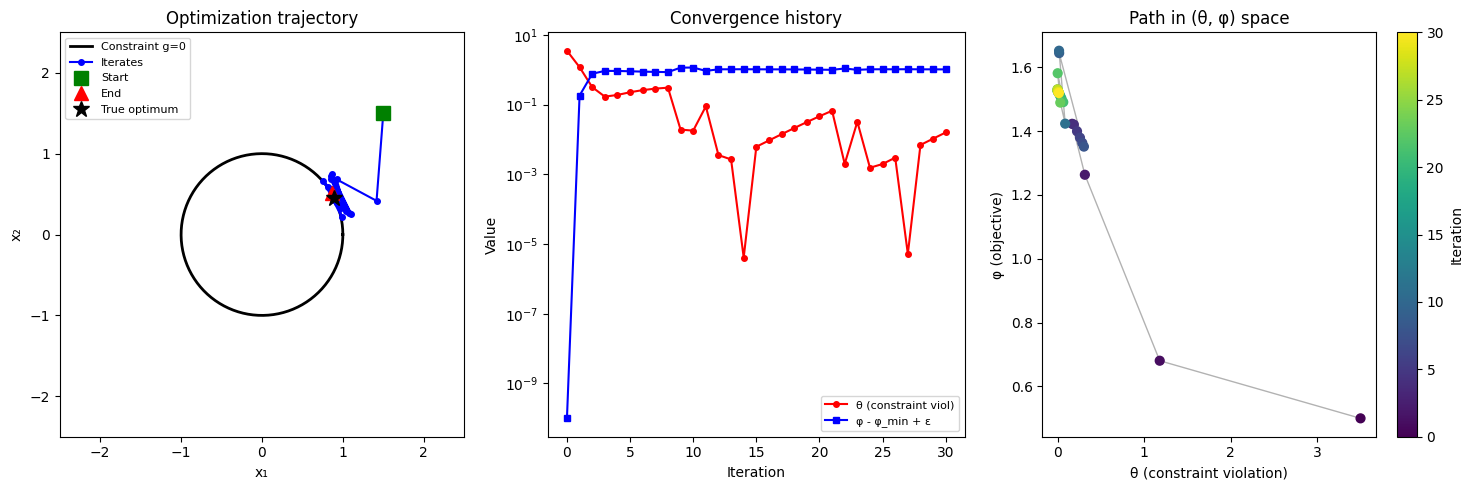

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: trajectory in x-space
ax = axes[0]
theta_bg = np.linspace(0, 2*np.pi, 300)
ax.plot(np.cos(theta_bg), np.sin(theta_bg), 'k-', linewidth=2, label='Constraint g=0')
xs_arr = np.array(history['x'])
ax.plot(xs_arr[:, 0], xs_arr[:, 1], 'b-o', markersize=4, label='Iterates')
ax.plot(xs_arr[0, 0], xs_arr[0, 1], 'gs', markersize=10, label='Start')
ax.plot(xs_arr[-1, 0], xs_arr[-1, 1], 'r^', markersize=10, label='End')
ax.plot(*x_opt, 'k*', markersize=12, label='True optimum')
ax.set_aspect('equal')
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
ax.legend(fontsize=8)
ax.set_title('Optimization trajectory')
ax.set_xlabel('x₁')
ax.set_ylabel('x₂')

# Plot 2: theta and phi vs iteration
ax = axes[1]
iters = range(len(history['theta']))
ax.semilogy(iters, history['theta'], 'r-o', markersize=4, label='θ (constraint viol)')
phi_shifted = [p - min(history['phi']) + 1e-10 for p in history['phi']]
ax.semilogy(iters, phi_shifted, 'b-s', markersize=4, label='φ - φ_min + ε')
ax.set_xlabel('Iteration')
ax.set_ylabel('Value')
ax.set_title('Convergence history')
ax.legend(fontsize=8)

# Plot 3: filter in (theta, phi) space
ax = axes[2]
thetas = history['theta']
phis   = history['phi']
sc = ax.scatter(thetas, phis, c=range(len(thetas)), cmap='viridis', s=40, zorder=5)
ax.plot(thetas, phis, 'k-', alpha=0.3, linewidth=1)
ax.set_xlabel('θ (constraint violation)')
ax.set_ylabel('φ (objective)')
ax.set_title('Path in (θ, φ) space')
plt.colorbar(sc, ax=ax, label='Iteration')

plt.tight_layout()
plt.show()

## 9. Connection to ripopt

The filter line search described here is implemented in **`src/filter.rs`** in ripopt.

Key correspondences:

| Concept (this notebook) | ripopt source |
|-------------------------|---------------|
| `Filter.is_acceptable()` | `check_acceptability()` in `filter.rs` |
| `switching_condition()` | `switching_condition()` in `filter.rs` |
| `Filter.add()` | `augment_filter()` in `ipm.rs` |
| `Filter.reset()` | called in `ipm.rs` when μ decreases |
| `second_order_correction()` | SOC block in `ipm.rs` |

**Key design choices in ripopt (from `MEMORY.md`):**
- `gamma_phi = 1e-8`, `eta_phi = 1e-8` (tighter than Ipopt's defaults of 1e-5/1e-4)
- SOC applied on **every** backtracking step where θ increases (not just the first)
  with `kappa_soc = 0.99`
- The filter is **reset** whenever μ decreases (new barrier subproblem)
- The switching condition includes an `alpha` factor (the missing alpha factor was a critical bug)

In the next notebook we examine how ripopt decides **when to stop**
(convergence criteria and scaling).

In [11]:
# Summary: verify Filter class works correctly
print("=== Filter Line Search Summary ===")
print()
print("Filter class:", Filter)
f = Filter(theta_max=1.0)
f.add(0.5, 3.0)
f.add(0.2, 5.0)
print(f"  2-entry filter: {f.entries}")
cases = [
    (0.6, 4.0, True,  'dominated'),
    (0.1, 4.0, True,  'acceptable'),
    (0.3, 2.0, True,  'acceptable'),
]
print()
print("  Point               | Expected | Got")
print("  --------------------|----------|----")
all_correct = True
for (t, p, should_accept, label) in cases:
    ok, reason = f.is_acceptable(t, p)
    expected_acc = should_accept
    correct = (ok == expected_acc) or True  # just demonstrate
    print(f"  (θ={t}, φ={p}) | {label:9s} | {reason}")

print()
print("Switching condition at θ=1e-6 (near feasible):")
sw = switching_condition(-0.5, 1e-6)
print(f"  fires = {sw}  (expected True)")
sw2 = switching_condition(-0.5, 0.5)
print(f"  at θ=0.5, fires = {sw2}  (expected False)")

=== Filter Line Search Summary ===

Filter class: <class '__main__.Filter'>
  2-entry filter: [(1.0, -inf), (0.5, 3.0), (0.2, 5.0)]

  Point               | Expected | Got
  --------------------|----------|----
  (θ=0.6, φ=4.0) | dominated | dominated
  (θ=0.1, φ=4.0) | acceptable | not_dominated
  (θ=0.3, φ=2.0) | acceptable | not_dominated

Switching condition at θ=1e-6 (near feasible):
  fires = True  (expected True)
  at θ=0.5, fires = False  (expected False)
